In [47]:
!pip install pingouin 
!pip install seaborn


[notice] A new release of pip is available: 23.2.1 -> 23.3.1
[notice] To update, run: python3.9 -m pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 23.3.1
[notice] To update, run: python3.9 -m pip install --upgrade pip


In [48]:
import os
import platform

import pandas as pd
import numpy as np
from gensim.models import KeyedVectors
from pingouin import ancova
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
import warnings

# RuntimeWarning 무시
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [50]:
os_system = platform.system() # 맥북은 Darwin, 윈도우는 Windows

# 현재 프로젝트 폴더 위치 지정. os.getcwd()는 지금 코드 실행하는 현 위치를 출력해줍니다.
study1_dir = os.getcwd()
model_path = '\\..\\pretrained\\GoogleNews-vectors-negative300.bin' if os_system == 'Windows' else '/../pretrained/GoogleNews-vectors-negative300.bin'

# data/processed 폴더 위치 지정
processed_data_dir = study1_dir + ('\\data\\processed\\' if os_system == 'Windows' else '/data/processed/')

# boxplots 이미지 저장할 폴더 위치 지정
graph_image_dir = study1_dir + ('\\graph\\ancova_boxplots' if os_system == 'Windows' else '/graph/ancova_boxplots')
# 폴더 없으면 생성
os.makedirs(graph_image_dir, exist_ok=True)


In [51]:
# 테이블 읽어오기
similarity_data = pd.read_csv(processed_data_dir + 'similarity_coherence_with_words.csv', encoding='ISO-8859-1')
survey_data = pd.read_csv(processed_data_dir + 'survey_data.csv', encoding='ISO-8859-1')

survey_data.drop([210], axis=0, inplace=True) # NaN

# 더미변수 생성
survey_data['Sex_Male'] = (survey_data['Sex'] == 'Male').astype(int)
survey_data['Sex_Female'] = (survey_data['Sex'] == 'Female').astype(int)

# Age 정수형으로 형변환
survey_data['Age'] = survey_data['Age'].astype(int)
survey_data[0:5]

,Participant Public ID,ID,Age,Sex,Race,Race_Quantised,Marital,Marital_Quantised,Education,Education_Quantised,...,Att_Session2_Quest_P2,AMAS,TAI,GQ,SVO,Group_SWLS,Group_MA,Group_MSPSS,Sex_Male,Sex_Female
0,5466464dfdf99b7fec4402b0,1.0,33,Female,white,6.0,partner,2.0,doctor,9.0,...,5.0,23.0,66.0,28.0,34.875328,1.0,2.0,1.0,0,1
1,54b60d74fdf99b1ce0367ab5,2.0,34,Female,white,6.0,partner,2.0,bachelor,6.0,...,5.0,36.0,64.0,27.0,12.824398,1.0,1.0,1.0,0,1
2,567f59e0d18c640011e7ac0b,3.0,35,Female,white,6.0,partner,2.0,high_quit,2.0,...,5.0,30.0,53.0,41.0,3.900494,2.0,1.0,2.0,0,1
3,56a68bb49ce1c0000df89344,4.0,35,Male,asian,1.0,single,1.0,bachelor,6.0,...,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1,0
4,56d8df02d13f6b000e542eef,5.0,25,Male,white,6.0,single,1.0,bachelor,6.0,...,5.0,21.0,29.0,26.0,7.815294,2.0,2.0,1.0,1,0


In [52]:
merged_df = pd.concat([similarity_data, survey_data], axis=1)
merged_df[0:3]

,subject,key1,key2,key3,key4,key5,key6,key7,key8,key9,...,Att_Session2_Quest_P2,AMAS,TAI,GQ,SVO,Group_SWLS,Group_MA,Group_MSPSS,Sex_Male,Sex_Female
0,1,card,bank,money,green,yellow,blue,eye,nose,smell,...,5.0,23.0,66.0,28.0,34.875328,1.0,2.0,1.0,0,1
1,2,lock,door,big,lion,roar,scary,ghost,dark,halloween,...,5.0,36.0,64.0,27.0,12.824398,1.0,1.0,1.0,0,1
2,3,door,window,curtain,draft,cold,snow,scarf,wooly hat,winter,...,5.0,30.0,53.0,41.0,3.900494,2.0,1.0,2.0,0,1


## ANOVA 분석 및 boxplot

In [53]:
# # 그래프 그리기
# def draw_boxplot(data, 
#                  between:str,
#                  dv: str,
#                  xticklabels: list,
#                  seed_word: str,
#                  target_word: str,
#                  p_value: float,
#                  filename: str):

#     plt.figure(figsize=(6,4))

#     # 박스 색상 없애고 가운데 선을 빨간색으로 표시
#     ax = sns.boxplot(x=between, y=dv, 
#                      data=data,
#                      width=0.15,
#                      boxprops=dict(facecolor="None", edgecolor="black"),
#                      medianprops=dict(color="red"))
#     ax.set(xticklabels=xticklabels)

#     plt.title(f'Seed word: {seed_word}')
#     plt.xlabel("")
#     plt.ylabel(f'Similarity with "{target_word}"')

#     ax.set_position([0.2, 0.2, 0.6, 0.6])
#     plt.text(0.5, 0.1, f'p = {round(p_value, 3)}', fontsize=10, ha='center')
#     # plt.show()
#     plt.savefig(filename, dpi=300) 

In [54]:
def plot_anova_boxplots(between, xticklabels):
    fig, axes = plt.subplots(2, 3, figsize=(14, 6), constrained_layout=True)
    plt.subplots_adjust(top=0.9, wspace=0.5, hspace=0.35)

    ax = axes.flatten()

    seed_words = ['key', 'money', 'friend']
    target_words = ['money', 'friend']

    i = 0
    for target in target_words:
        for seed in seed_words:
            # ANCOVA 실행
            ancova_result = ancova(data=merged_df, dv=f'coherence_{seed}_{target}', between=between, covar=['Age', 'Sex_Female', 'Sex_Male'])
            p_value = ancova_result['p-unc'].tolist()[0]
            print(f"ANCOVA 분석결과 - seed: {seed}, target: {target}")
            print(ancova_result)
            print()

            # 각 그래프에 대한 설정
            sns.boxplot(x=between,
                        y=f'coherence_{seed}_{target}', 
                        data=merged_df,
                        width=0.15,
                        boxprops=dict(facecolor="None", edgecolor="black"),
                        medianprops=dict(color="red"),
                        ax=ax[i])
            ax[i].set_title("")
            ax[i].set_xlabel("")
            ax[i].set_ylabel("")

            if i in [0, 3]:
                ax[i].set_ylabel(f"Similarity with \"{target}\"" , fontsize= 15)
            if i in [0, 1, 2]:
                ax[i].set_title(f'Seed word: {seed}' , fontsize= 15)
            ax[i].set(xticklabels=xticklabels)

            # p-value 텍스트 추가
            ax[i].text(0.5, 0.1, f'p = {round(p_value, 3)}', fontsize=12, ha='center')
            i += 1
    # 전체 그리드 이미지를 저장
    filepath =  (f'\\{graph_image_dir}\\ancova_boxplots_{between}.png' if os_system == 'Windows' else f'/{graph_image_dir}/ancova_boxplots_{between}.png')
    plt.savefig(filepath, dpi=300)

    # 화면에 그리드 이미지 표시
    plt.show()


ANCOVA 분석결과 - seed: key, target: money
       Source        SS   DF         F     p-unc       np2
0  Group_SWLS  0.000002    1  0.003260  0.954527  0.000016
1         Age  0.000035    1  0.056437  0.812456  0.000275
2  Sex_Female  0.000306    1  0.500660  0.480014  0.002436
3    Sex_Male  0.000370    1  0.604550  0.437744  0.002940
4    Residual  0.125387  205       NaN       NaN       NaN

ANCOVA 분석결과 - seed: money, target: money
       Source        SS   DF         F     p-unc       np2
0  Group_SWLS  0.001399    1  1.588224  0.209013  0.007688
1         Age  0.002662    1  3.022736  0.083606  0.014531
2  Sex_Female  0.008199    1  9.309041  0.002582  0.043437
3    Sex_Male  0.008469    1  9.615185  0.002201  0.044802
4    Residual  0.180562  205       NaN       NaN       NaN

ANCOVA 분석결과 - seed: friend, target: money
       Source        SS   DF         F     p-unc       np2
0  Group_SWLS  0.001899    1  2.545689  0.112136  0.012266
1         Age  0.000064    1  0.086322  0.769204  

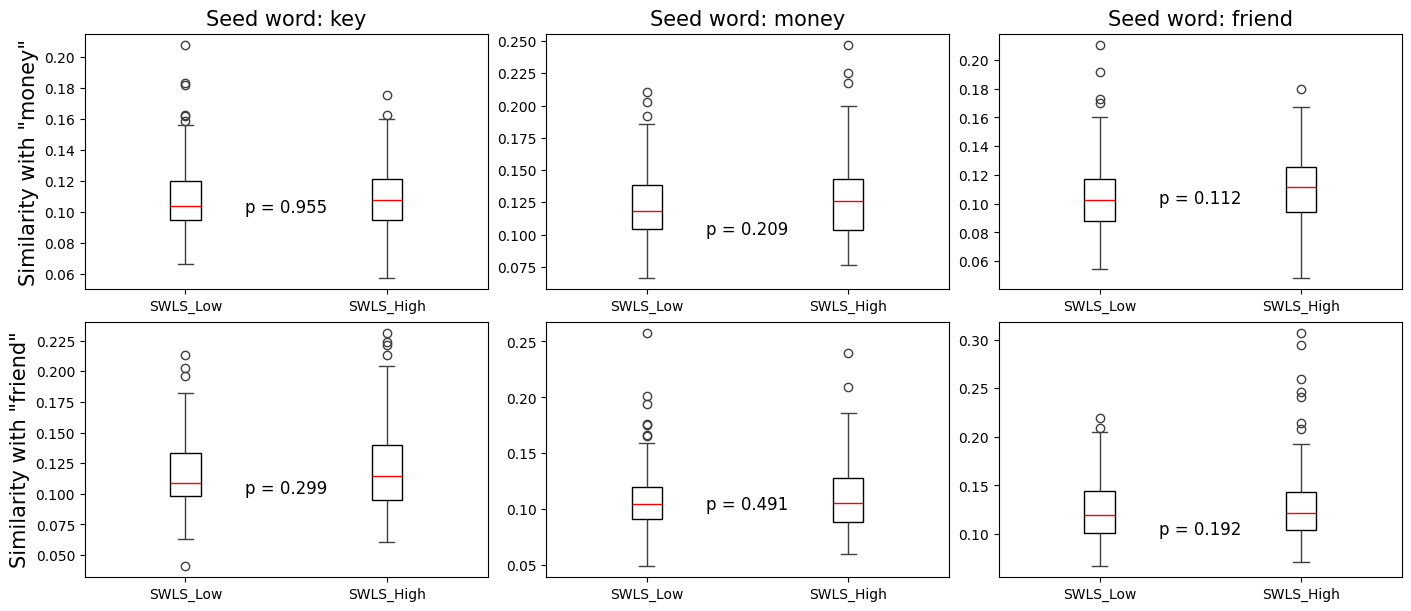

In [55]:
plot_anova_boxplots('Group_SWLS', xticklabels=['SWLS_Low', 'SWLS_High'])

ANCOVA 분석결과 - seed: key, target: money
       Source        SS   DF         F     p-unc       np2
0    Group_MA  0.000155    1  0.253080  0.615455  0.001233
1         Age  0.000054    1  0.088073  0.766942  0.000429
2  Sex_Female  0.000342    1  0.559715  0.455233  0.002723
3    Sex_Male  0.000406    1  0.665021  0.415740  0.003234
4    Residual  0.125234  205       NaN       NaN       NaN

ANCOVA 분석결과 - seed: money, target: money
       Source        SS   DF          F     p-unc       np2
0    Group_MA  0.000068    1   0.076649  0.782170  0.000374
1         Age  0.002148    1   2.421386  0.121231  0.011674
2  Sex_Female  0.008807    1   9.925912  0.001873  0.046183
3    Sex_Male  0.009200    1  10.368548  0.001491  0.048143
4    Residual  0.181893  205        NaN       NaN       NaN

ANCOVA 분석결과 - seed: friend, target: money
       Source        SS   DF         F     p-unc       np2
0    Group_MA  0.001217    1  1.624405  0.203921  0.007862
1         Age  0.000002    1  0.002097  0.96

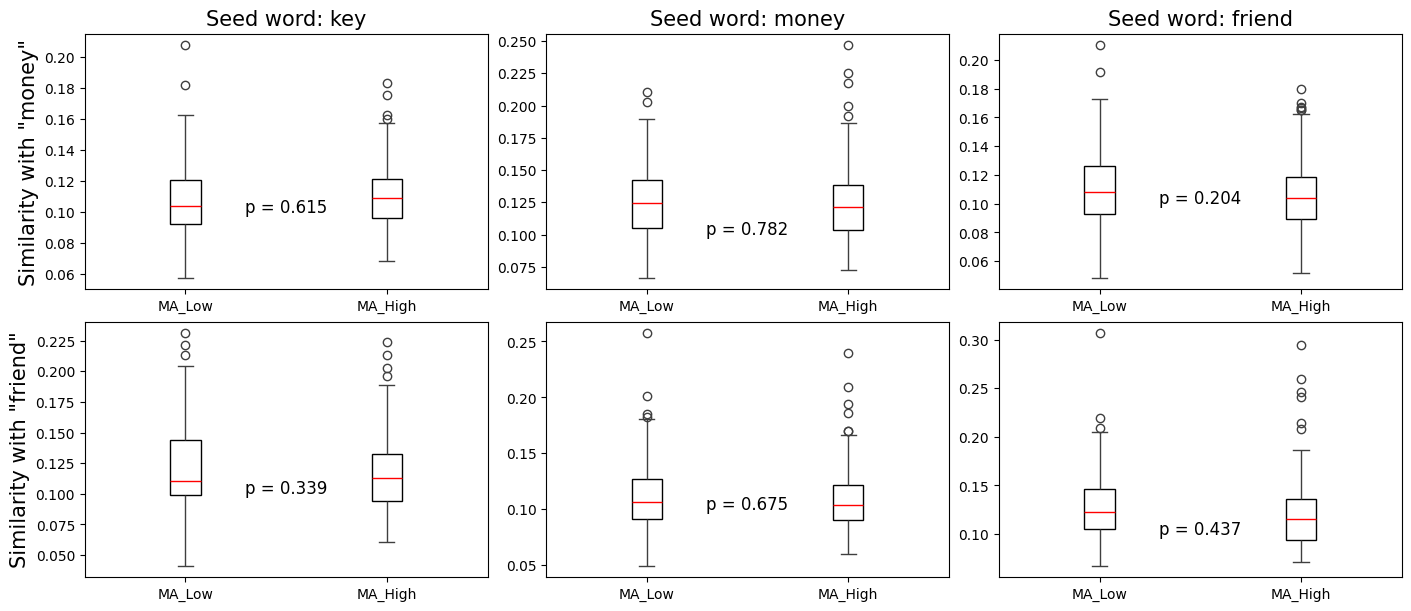

In [56]:
plot_anova_boxplots('Group_MA', xticklabels=['MA_Low', 'MA_High'])

ANCOVA 분석결과 - seed: key, target: money
        Source        SS   DF         F     p-unc       np2
0  Group_MSPSS  0.000008    1  0.013154  0.908804  0.000064
1          Age  0.000028    1  0.046522  0.829444  0.000227
2   Sex_Female  0.000296    1  0.483754  0.487514  0.002354
3     Sex_Male  0.000357    1  0.582957  0.446033  0.002836
4     Residual  0.125381  205       NaN       NaN       NaN

ANCOVA 분석결과 - seed: money, target: money
        Source        SS   DF         F     p-unc       np2
0  Group_MSPSS  0.000301    1  0.339667  0.560662  0.001654
1          Age  0.002471    1  2.788272  0.096483  0.013419
2   Sex_Female  0.008471    1  9.558840  0.002267  0.044551
3     Sex_Male  0.008802    1  9.933230  0.001866  0.046215
4     Residual  0.181660  205       NaN       NaN       NaN

ANCOVA 분석결과 - seed: friend, target: money
        Source        SS   DF         F     p-unc       np2
0  Group_MSPSS  0.001106    1  1.474274  0.226069  0.007140
1          Age  0.000059    1  0.078

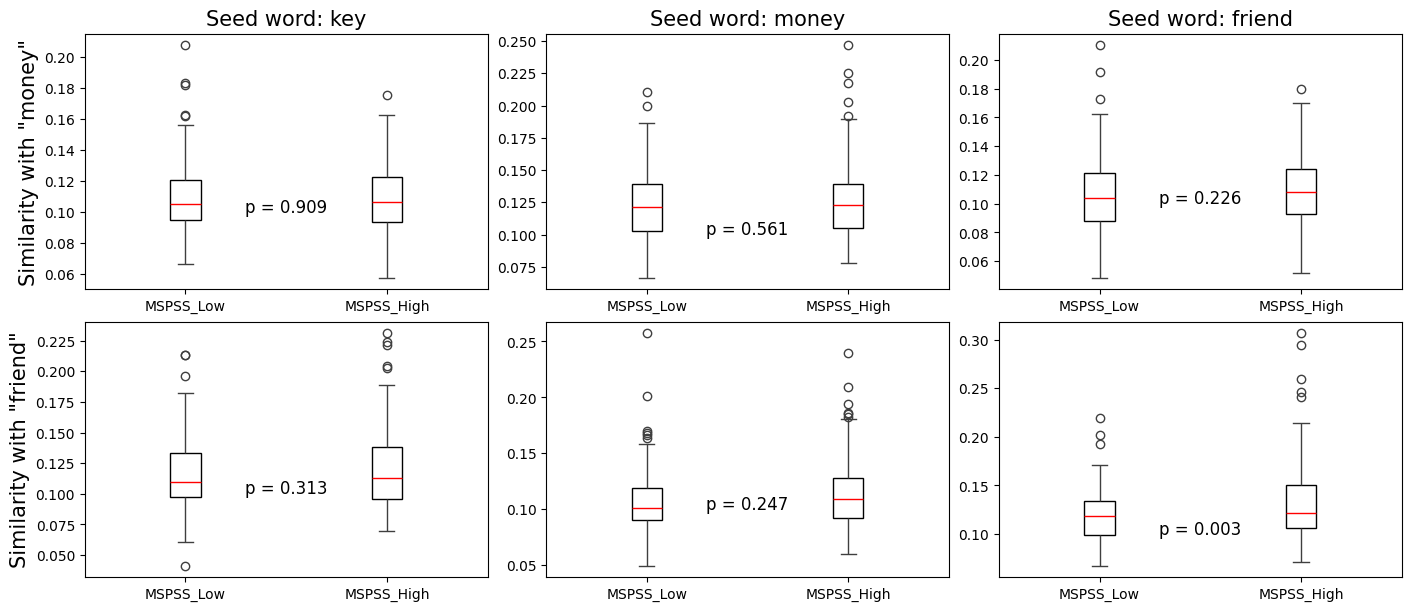

In [57]:
plot_anova_boxplots('Group_MSPSS', xticklabels=['MSPSS_Low', 'MSPSS_High'])